**Student Name** : Pandadiya Dharak Sanjaybhai 

**Module** : M505A Intro to AI and Machine Learning

**GH Number** : GH1057786

**Dataset** : Hotel Booking Cancellation Prediction

### Hotel Booking Cancellation Prediction ML Project
This project titled "Hotel Booking Cancellation Prediction Machine Learning Project" is largely about studying hotel booking data for understanding what factors lead to cancellation of reservations and predicting future chances of cancellations. Using Hotel Booking Demand Dataset, which is much publicized and easily obtainable, we are going to study those factors which cause cancellations and create good predictive modeling for hotels to manage better their bookings and minimize losses coming from cancellations. 

Github Repository: https://github.com/dharak07/Intro-to-AI-and-Machine-Learning.git

Source: https://www.kaggle.com/datasets/youssefaboelwafa/hotel-booking-cancellation-prediction


### Problem Statement
Cancellations of hotel reservations pose a huge challenge to the hotel due to lost earnings and the difficulty in managing their rooms. Knowing the elements affecting cancellations will help the hotels improve the planning of their reservations and thus satisfy their clients.

### Why it is Important?
-	Decreasing cancelations of reservations can allow hotels to earn higher income and increase the number of rooms that are rented out.
-	Understanding cancellation behavior aids the hospitality industry in better tariff setting, reservation arrangement, and resource management.

### How Solving This Problem Will Benefit the Company
By predicting hotel booking cancellations, hotels can:
-	Minimize Revenue Losses : Detect reservations that may be canceled and implement measures to prevent further damage.
-	Achieve Better Reservation Management : Utilize information about anticipated cancellations to optimize revenue management approach.

In [1]:
import pandas as pd
import plotly.express as pltx
import seaborn as sns
import numpy as np

### Data Exploration Insights

In [2]:
dff = pd.read_csv("../Data/booking.csv")
df = dff.copy()
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


Observation : Through out observation there is customer data with customer details such as, stay duration, meal preferences, parking requirements, room types, lead time, pricing, reservation dates, and booking status. It provides useful information for analyzing booking trends, customer behavior, and predicting booking cancellations.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

Observation : That shows a list of data types.

In [7]:
room_price = df.groupby('room type')['average price'].mean().reset_index()

fig = pltx.bar(
    room_price,
    x='room type',
    y='average price',
    title='Average Room Price by Room Type',
    labels={'room type': 'Room Type', 'average price': 'Average Price'},
    text_auto=True,
    color='average price',
    color_continuous_scale="Blues"
)

fig.show()

Observation : In our observation, we can see that the average Room Price varies according to room types with the higher room types usually having higher average prices since premium rooms in general will usually have a higher price than the standard rooms.

In [8]:
if df['room type'].dtypes == 'object':
    df['room type'] = df['room type'].astype('category')

room_vs_price = df.groupby('room type', observed=True)['average price'].mean().reset_index()

fig = pltx.pie(
    room_vs_price,
    names='room type',
    values='average price',
    title='Average Room Price by Room Type',
    hole=0.4,
    color_discrete_sequence=pltx.colors.qualitative.Set3
)

fig.show()

Observation : The Average Room Price by room type indicates that the average prices vary according to the room type. For example, the room type that has the maximum share claims the highest average room price, whereas other types with lesser shares indicate lower average prices.

In [10]:
fig = pltx.violin(
    df,
    x="room type",
    y="average price",
    color="room type",
    box=True,
    points="all",
    title="Average Room Price Distribution by Room Type",
    labels={
        "room type": "Room Type",
        "average price": "Average Room Price"
    }
)

fig.show()

Observation : Average Room Price Distribution per Room Type provides us great opportunity to analyze differences in room prices for various type of rooms. 

### Correlation HeatMAP

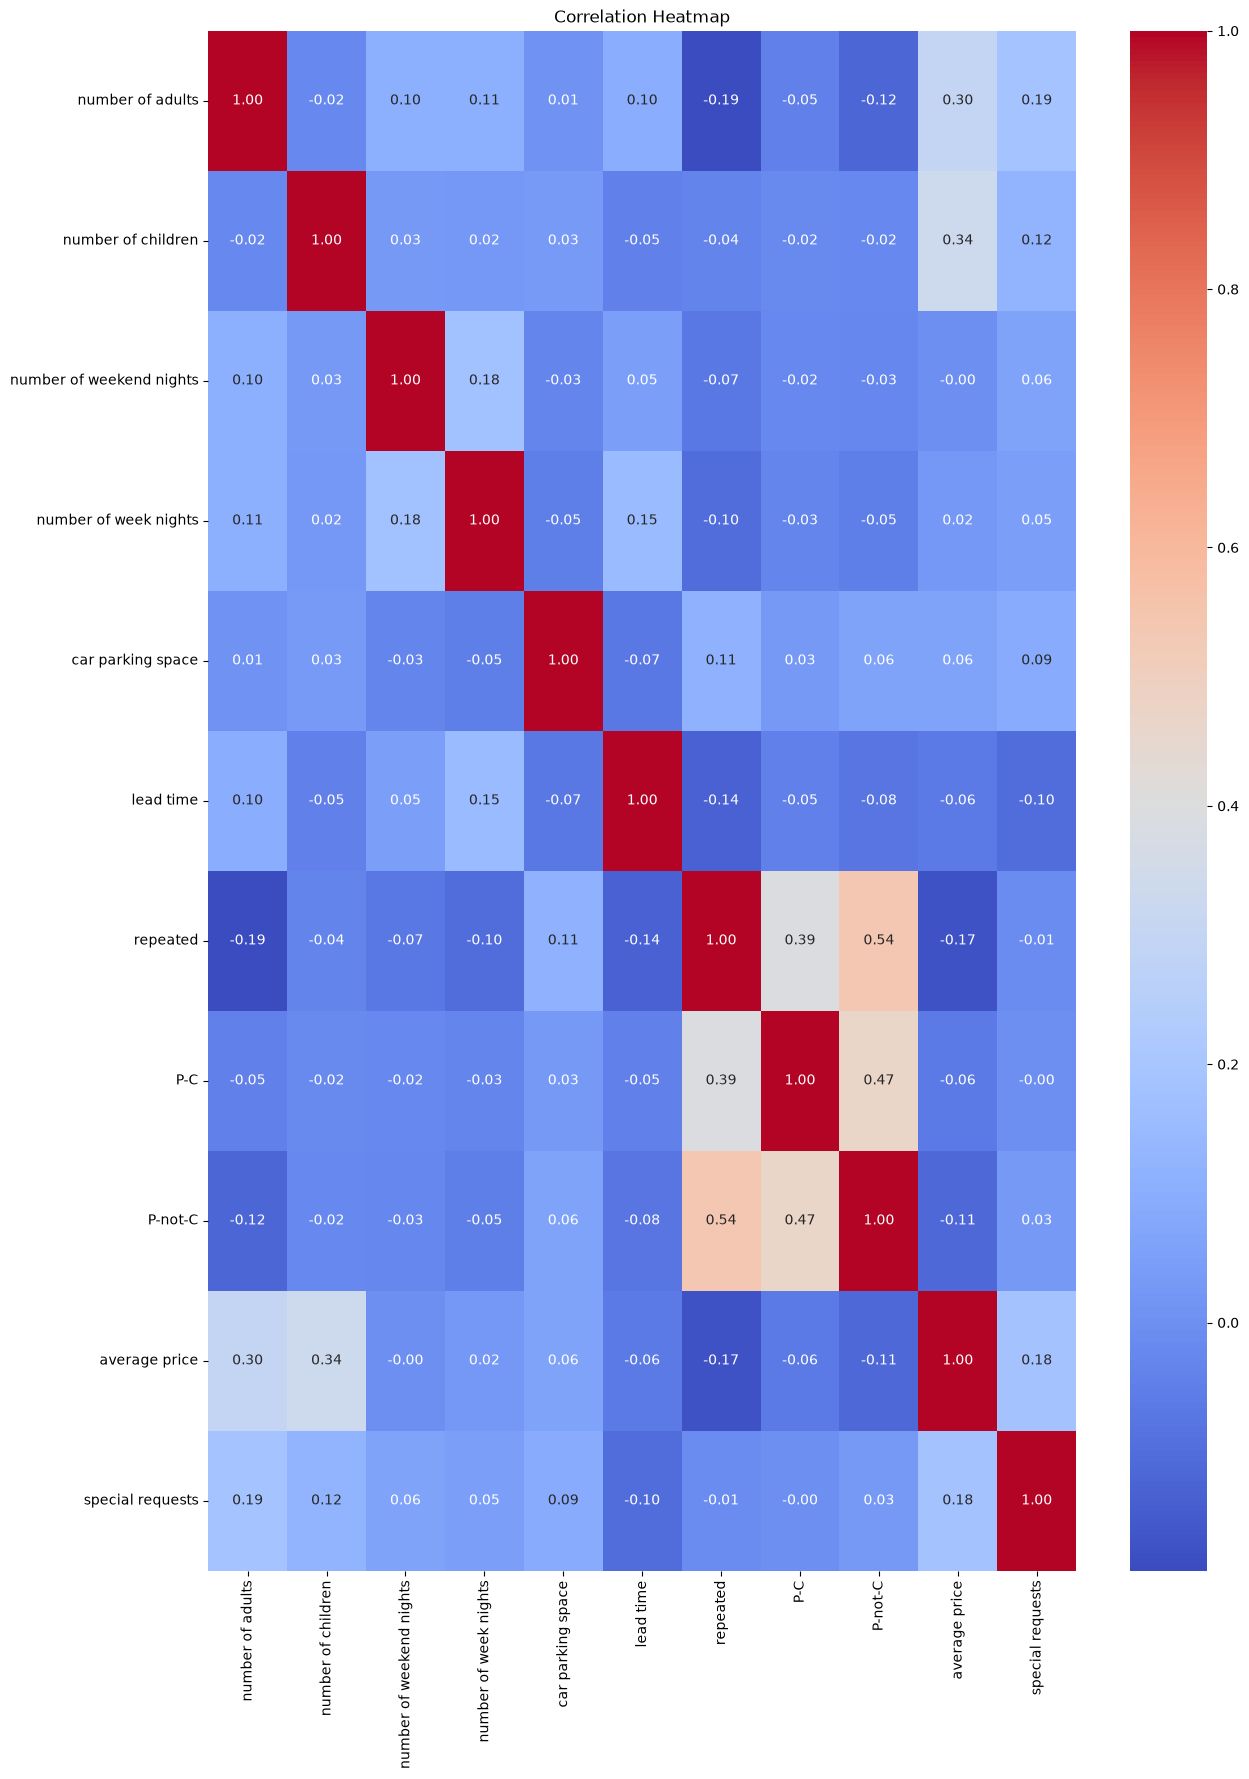

In [12]:
import matplotlib.pyplot as plt

numerica_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(14,20))
sns.heatmap(
    numerica_cols.corr(), 
    annot=True, 
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

Observation : According to the heatmap, there exist apparent links among Lead Time, Average Price, and Stay Duration with other booking attributes. However, in general, there are weak to moderate correlations amongst most of the variables indicating that various factors are in play with regard to hotel booking behaviour.

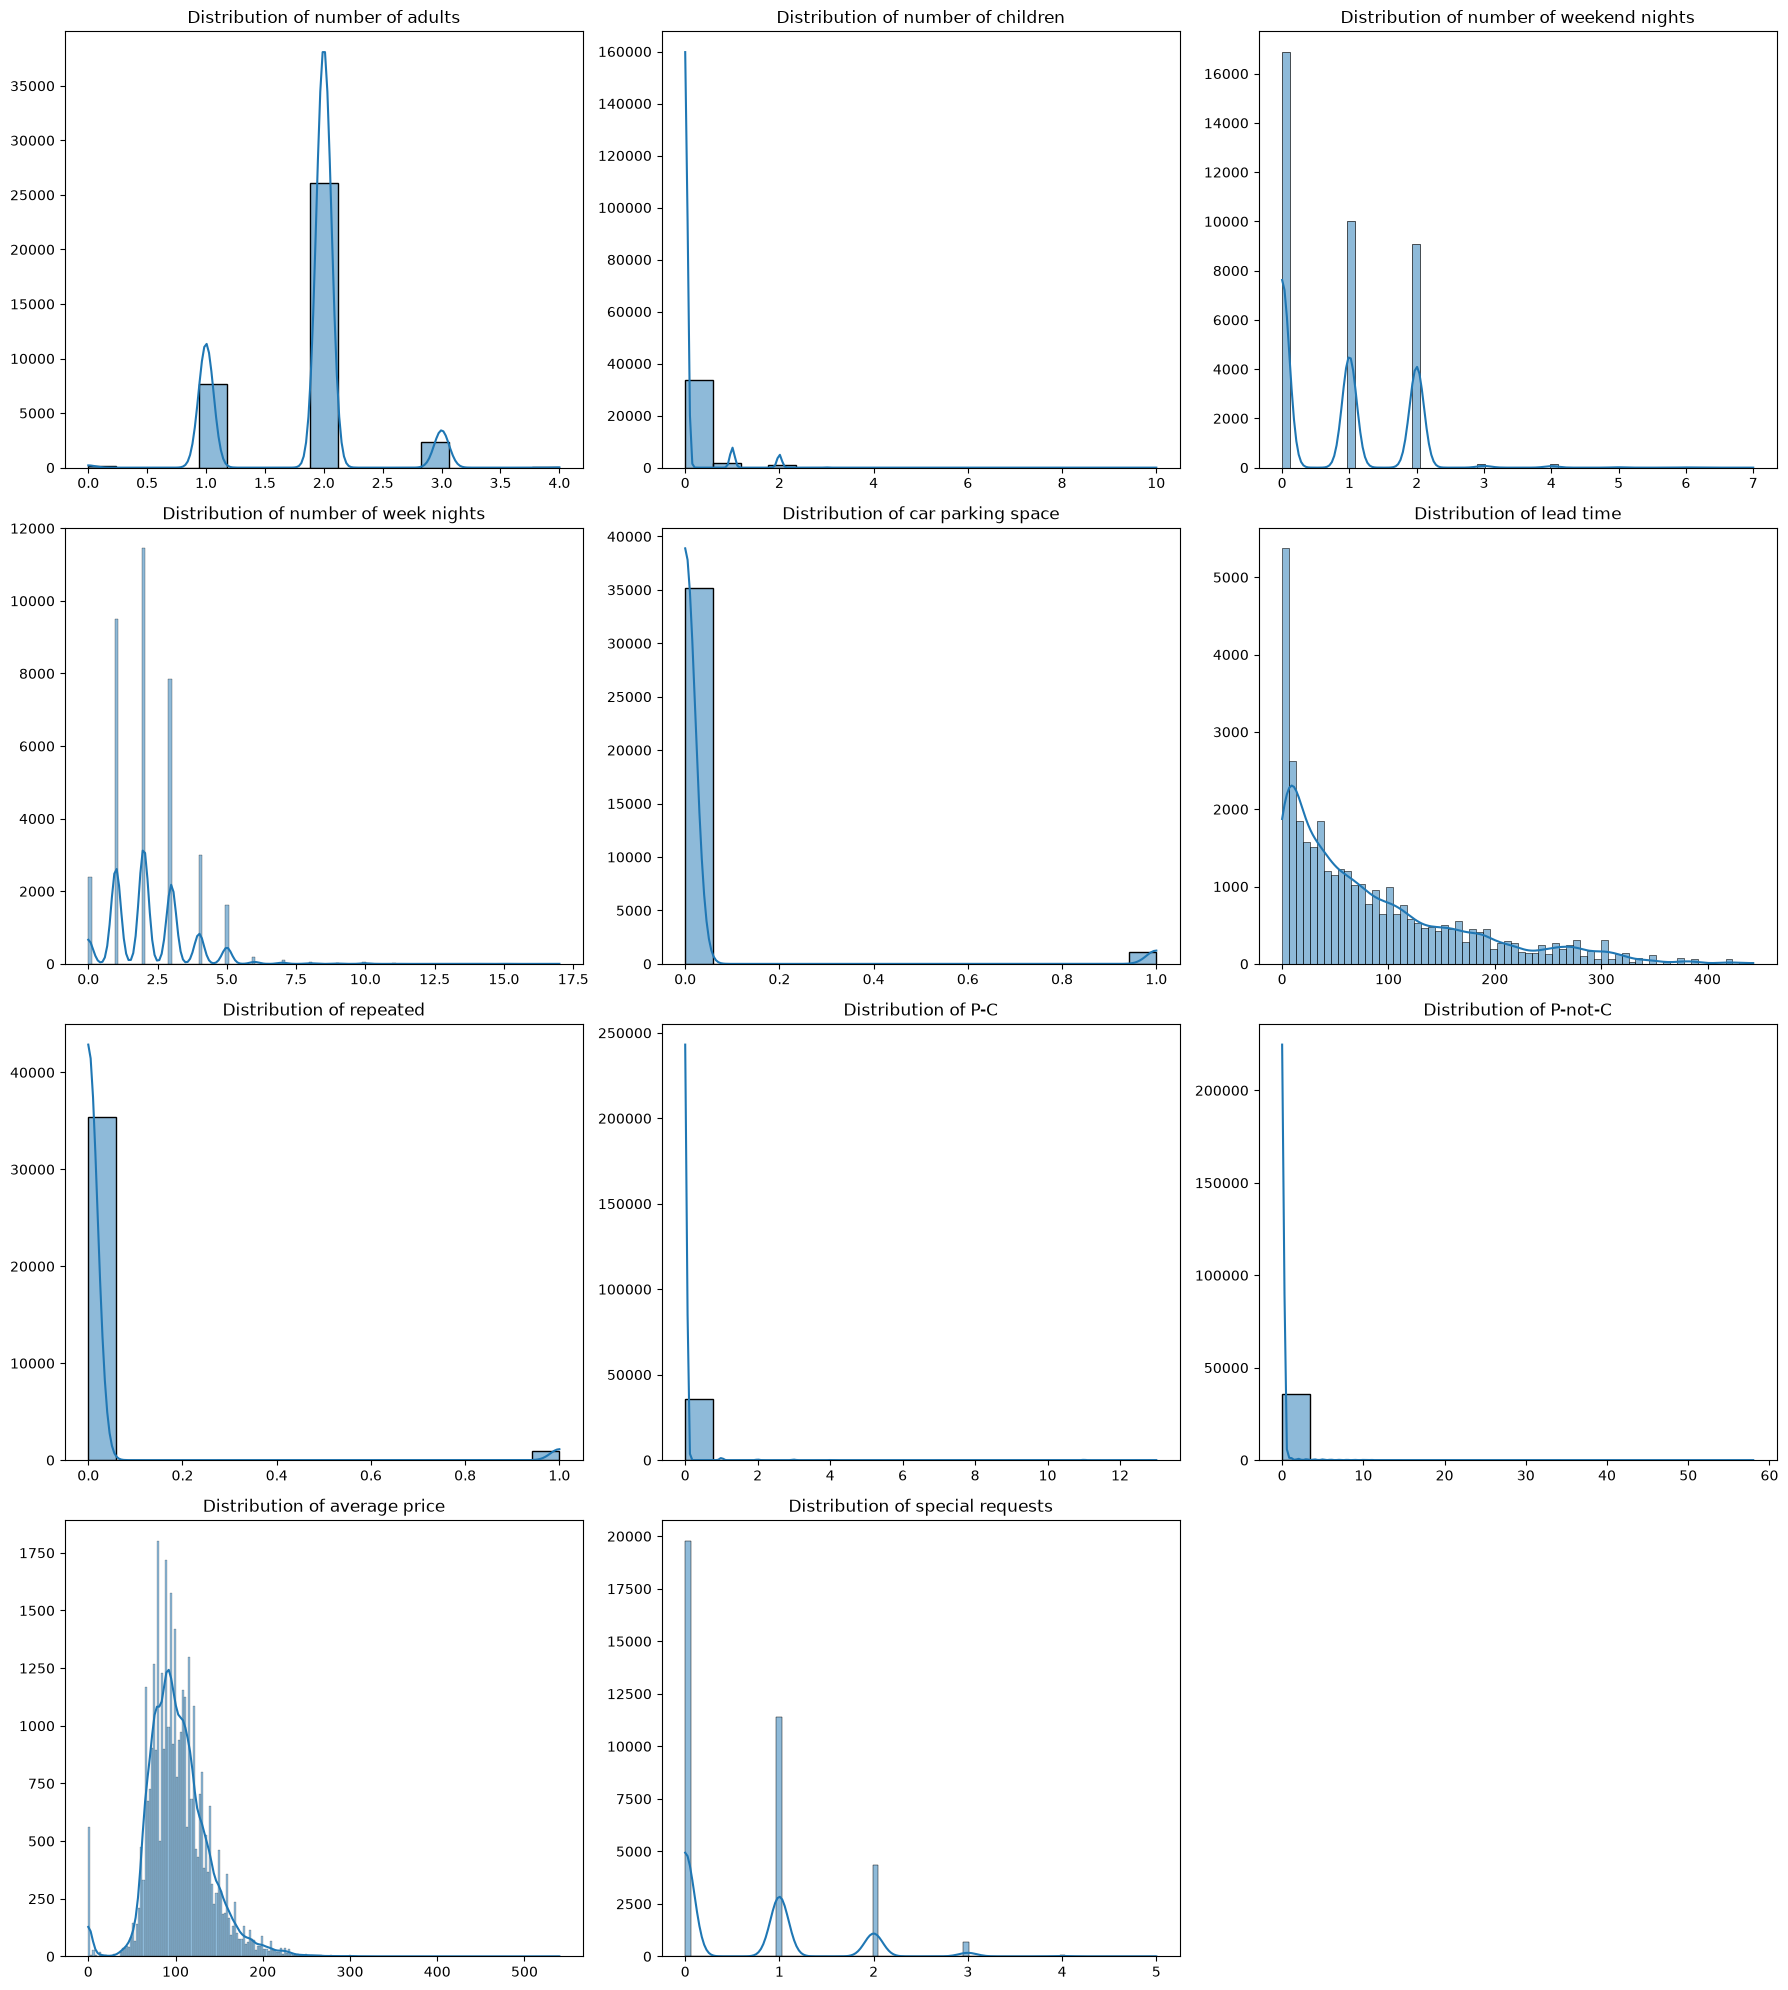

In [13]:
fig,axes = plt.subplots(nrows=4,ncols=3,figsize=(18,20))
axes = axes.flatten()
for i, col in enumerate(numerica_cols):
    if i < len(axes):
        sns.histplot(df[col], ax=axes[i], kde=True)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        break
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observation : The histogram images indicate that several of the hotel booking variables exhibit the phenomenon of many variables taking different shapes.

In [14]:
import pandas as pd
import plotly.express as pltx

# Convert categorical columns into numerical codes
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = pd.Categorical(df[col]).codes

# Calculate correlation
df_correlation = df.corr(numeric_only=True)

# Create correlation heatmap
fig = pltx.imshow(
    df_correlation,
    title="Hotel Booking Correlation Matrix",
    labels=dict(color="Correlation"),
    color_continuous_scale="Viridis"
)

fig.show()

Observation : It represent Correlation Matrix Heatmap base on data. Variables with values that are close to +1 or -1 showcase a strong correlation, whereas the values that are near to 0 signal a weak correlation.

In [15]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = pd.Categorical(df[col]).codes

df_correlation = df.corr(numeric_only=True)

features = df_correlation['date of reservation'].sort_values(ascending=False).drop('date of reservation')

fig = pltx.bar(
    x=features.values,
    y=features.index,
    title="Feature Correlation with Date of Reservation",
    color=features.values,
    orientation='h',
    color_continuous_scale="Plasma"
)

for i in range(len(features)):
    fig.add_annotation(
        x=features.values[i],
        y=features.index[i],
        text=f"{features.values[i]:.2f}",
        xshift=10 if features.values[i] < 0 else -10,
        showarrow=False,
    )

fig.update_layout(
    xaxis_title="Correlation with Date of Reservation",
    yaxis_title="Features"
)   

fig.show()

Observation : According to analysis, the average price is the most positively correlated variable with the date of reservation with a correlation coefficient 0.23, and it is followed by the number of adults (0.11), and lead time (0.09).

### Feature Engineering

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [19]:
dk = df.drop(columns=['booking status'], errors='ignore')
categorial_features = ['room type']
numerical_features = ['number of weekend nights', 'special requests', 'number of adults', 'number of children', 'number of week nights']

Observation : Categorical attribute identified by the categorization analysis is room type, whereas weekend nights, week nights, adults, children, and special requests are identified as numerical attributes.

### K Means Clustering

In [20]:
df = df.copy()

numerical_features = [
    'lead time',
    'average price',
    'number of adults',
    'number of children',
    'number of weekend nights',
    'number of week nights',
    'special requests'
]

#Create clustering dataset
dk = df[numerical_features].copy()

# Convert columns to numeric
for col in numerical_features:
    df[col] = pd.to_numeric(dk[col], errors='coerce')

# Fill missing values
for col in numerical_features:
    dk[col] = dk[col].fillna(dk[col].mean())

# Standardize numerical features
scaler = StandardScaler()
dk[numerical_features] = scaler.fit_transform(dk[numerical_features])

# Check for missing values
assert dk.isnull().sum().sum() == 0, "There are still NaN values!"

# Test different numbers of clusters
inertia = []
silhouette_scores = []

k_range = range(2, 8)

for k in k_range:
    print(f"Training KMeans with {k} clusters")

    k_means = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    k_means.fit(dk)

    inertia_ = k_means.inertia_
    silhouette_scores_ = silhouette_score(dk, k_means.labels_)

    inertia.append(inertia_)
    silhouette_scores.append(silhouette_scores_)

    print("Inertia:", inertia_)
    print("silhouette score:", silhouette_scores_)
    print('')

Training KMeans with 2 clusters
Inertia: 217668.66653539182
silhouette score: 0.1874394851430911

Training KMeans with 3 clusters
Inertia: 188817.22767552157
silhouette score: 0.15459621279215618

Training KMeans with 4 clusters
Inertia: 165766.34291086774
silhouette score: 0.1705361518893703

Training KMeans with 5 clusters
Inertia: 149622.55403175327
silhouette score: 0.1932618462668953

Training KMeans with 6 clusters
Inertia: 136037.08462834748
silhouette score: 0.1952263318761381

Training KMeans with 7 clusters
Inertia: 125107.781127667
silhouette score: 0.20268060991871573



Observation : As part of its analysis, the research uses the K-Means technique to determine how many clusters there are from 2 to 7 and discovers that the inertia declines whilst the number of clusters increases. 

### K-Means Clustering Summary
- K-Means Clustering process applied the K Means algorithems with different vlaues.
- Evalute optimal numbers of cluster using evaluated scores.

### Model Training

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import time

# Target variable
X = df.drop(columns=["booking status"])
y = df["booking status"]

# Encode target
y = LabelEncoder().fit_transform(y)

# Categorical and numerical features
categorical_features = [
    "type of meal",
    "room type",
    "market segment type",
    "repeated"
]

numerical_features = [
    "lead time",
    "number of adults",
    "number of children",
    "number of weekend nights",
    "number of week nights",
    "average price",
    "special requests"
]

# Encode categorical columns
for col in categorical_features:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Scale numerical columns
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

print(
    f"X_train shape: {X_train.shape}, "
    f"X_test shape: {X_test.shape}, "
    f"y_train shape: {y_train.shape}, "
    f"y_test shape: {y_test.shape}"
)

X_train shape: (29028, 17), X_test shape: (7257, 17), y_train shape: (29028,), y_test shape: (7257,)


Observation : The analysis takes the Methods of processing enable classification of booking data into two sets: a training one with 29,028 records and a testing one with 7,257 records.Further, there are six machine learning models created to classify the booking status.

### Pre-Processing

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

x = df.drop(columns=["booking status"], errors='ignore')
y = df["booking status"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ("standard_scaler", StandardScaler(), numerical_features),
        ("one_hot_encoder", OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
).fit(X_train)

# Transform the training and testing data
X_train = preprocessor.transform(X_train)
X_test = preprocessor.transform(X_test)

# Encode target variable
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

# Train each model
for model_name, model in models.items():
    print(f"Training {model_name}")
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    print(
        f"Training {model_name} complete "
        f"time taken: {end_time - start_time:.2f} seconds\n"
    )

Training Logistic Regression
Training Logistic Regression complete time taken: 0.20 seconds

Training Random Forest
Training Random Forest complete time taken: 2.49 seconds

Training Gradient Boosting
Training Gradient Boosting complete time taken: 3.25 seconds

Training SVM
Training SVM complete time taken: 28.57 seconds

Training Naive Bayes
Training Naive Bayes complete time taken: 0.02 seconds

Training KNN
Training KNN complete time taken: 0.00 seconds



Observation : For this study, the six classifiers—Logistic Regression, Random Forest, Gradient Boosting, SVM, Naive Bayes, and KNN—across six methods, have been developed, trained, and tested on the prepared booking data, to ensure their performance evaluation and comparison in terms of training time and prediction performance.

In [24]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_absolute_error


# Features and target
X = df.drop(columns=["booking status"], errors='ignore')
y = LabelEncoder().fit_transform(df["booking status"])

# Categorical features
categorical_features = [
    "type of meal",
    "room type",
    "market segment type",
    "repeated"
]

# Numerical features
numerical_features = [
    "lead time",
    "number of adults",
    "number of children",
    "number of weekend nights",
    "number of week nights",
    "average price",
    "special requests"
]

# Preprocessing
preprocessor = ColumnTransformer([
    ("scale", StandardScaler(), numerical_features),
    ("encode", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(preprocessor.fit_transform(X),
    y,
    test_size=0.2,
    random_state=42
)

# Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

# Store results
results = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    results[name] = {
        "Accuracy": accuracy_score(y_train, y_pred),
        "F1": f1_score(y_train, y_pred, average="weighted"),
        "Recall": recall_score(y_train, y_pred, average="weighted"),
        "Precision": precision_score(y_train, y_pred, average="weighted"),
        "MAE": mean_absolute_error(y_train, y_pred),
        "Time": round(time.time() - start, 2)
    }

# Results DataFrame
results_df = pd.DataFrame(results).T
fig = pltx.bar(
    results_df,
    x=results_df.index,
    y=["Accuracy", "F1", "Recall", "Precision", "MAE"],
    title="Model Performance",
    barmode="group",
)
fig.show()

Observation : According to the findings from the results, it can be understood that Random Forest has the highest performance in terms of achieving an accuracy of 99.2% and the lowest value of MAE at 0.008. KNN came in second with an accuracy of 89.5%. On the contrary, Naive Bayes showed the lowest performance, which proves the effectiveness of the Random Forest model.

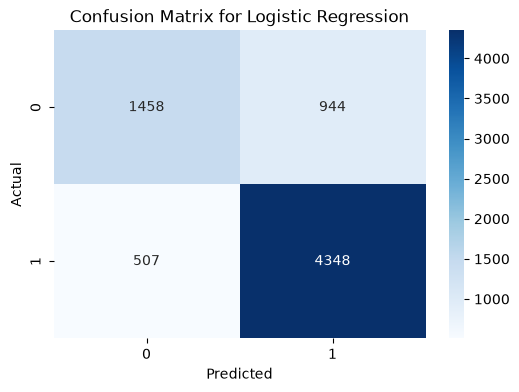

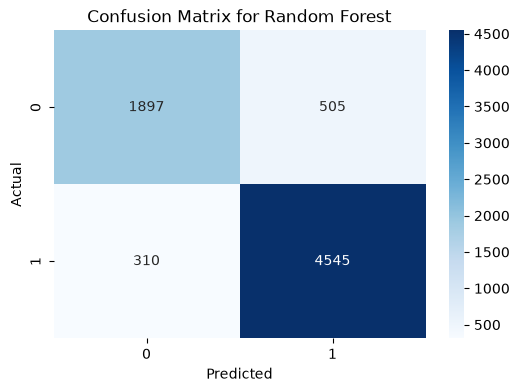

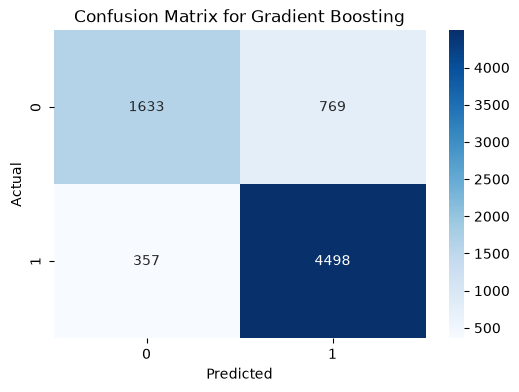

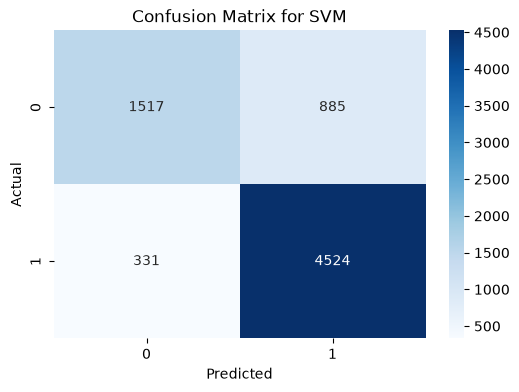

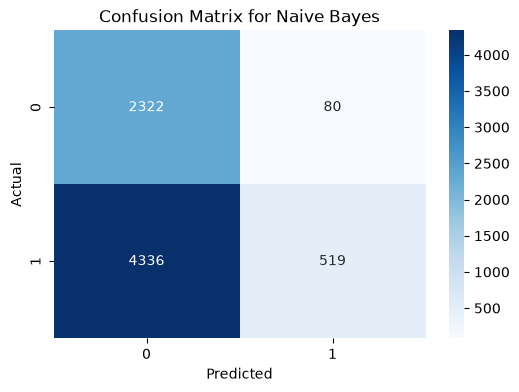

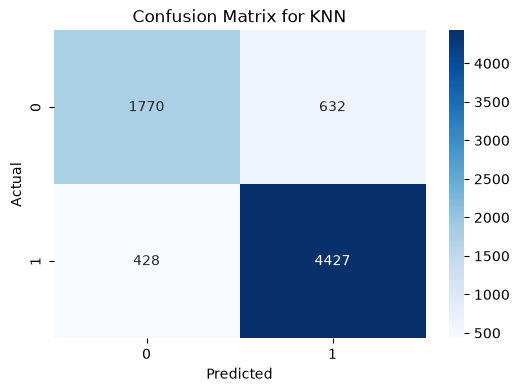

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Observation : Upon conducting an analysis of the confusion matrix it becomes apparent that the Random Forest is the most accurate in terms of error count when compared to other algorithms. Although KNN and Gradient Boosting methods are producing satisfactory results, in terms of error level, Naive Bayes is performing the worst.

### Hyperparameter Tuning for RandomForestClassifier

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
}

rf_model = RandomForestClassifier(random_state=42)

start_time = time.time()
rf_tuner = RandomizedSearchCV(
    rf_model, param_distributions=rf_param_grid, 
    n_iter=20, cv=5, random_state=42, n_jobs=-1
)
rf_tuner.fit(X_train, y_train)

y_pred_rf_tuned = rf_tuner.predict(X_test)
tuning_duration = time.time() - start_time

best_rf_params = rf_tuner.best_params_
best_rf_score = rf_tuner.best_score_

print(f"Best Parameters: {best_rf_params}")
print(f"Best Score: {best_rf_score}")
print(f"Tuning Duration: {tuning_duration:.4f} seconds")

Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 30, 'bootstrap': False}
Best Score: 0.8820446934369179
Tuning Duration: 89.4899 seconds


Observation : The tuning of the Random Forest model is conducted using RandomizedSearchCV by testing possibly many combinations of the values for the parameters of the random forest model while utilizing a 5-fold cross-validation technique.

In [27]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

rf_original = RandomForestClassifier(random_state=42)
rf_original.fit(X_train, y_train)
y_pred_original = rf_original.predict(X_test)

y_pred_tuned = rf_tuner.predict(X_test)

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
    }

original_rf_metrics = evaluate_model(y_test, y_pred_original)
tuned_rf_metrics = evaluate_model(y_test, y_pred_tuned)

performance_df = pd.DataFrame({"Original RF": original_rf_metrics, "Tuned RF": tuned_rf_metrics})

print("Model Performance Comparison (Original vs Tuned RandomForest):")
display(performance_df)

import plotly.express as px
fig = px.bar(
    performance_df.T,
    barmode="group",
    title="Performance Comparison: Original vs Tuned RandomForest",
)
fig.show()

Model Performance Comparison (Original vs Tuned RandomForest):


,Original RF,Tuned RF
Accuracy,0.888659,0.886041
F1 Score,0.887393,0.884072
Recall,0.888659,0.886041
Precision,0.887597,0.885262


Observation : The comparison of the Original vs. the Tuned Random Forest Models is done on the basis of some parameters such as accuracy, F1 score, recall, and precision. The purpose of comparison is to find out whether the tuned model performs better than the Original model in terms of prediction or not.

### Conclusion

### Project Summary and Findings
The subject of this endeavor is the analysis of hotel bookings and cancellations via ML methods. The analysis was performed on an important hotel bookings dataset in order to find the patterns and the factors that cause cancellations and to create a model for predicting the status of bookings (either Canceled or Not Canceled).

### Key Insights  
- Most of the reservations fall under Not_Canceled class.
- Majority of bookings are made with 2 adults participating.
- Most of the bookings have no children included.

### Business Recommendation 
- Cancellations Reduction : Monitor reservations and remind clients about them through both emails and texts prior to their visit.
- Encouraging Luxury Rooms Bookings : Offer a discount to guests for making hotel bookings in high-rated hotels.
- Customer Service Improvement : Respond to requests of the customers to improve the service level.